# Spin-orbit coupling

`noncolin = .true.` makes a wavefunction a two-component spinor, so there is **one**
Hamiltonian on a space twice as large rather than two Hamiltonians, and
`lspinorb = .true.` puts the $j$-resolved projectors of a fully-relativistic dataset into
it. Three platinum benchmarks, ultrasoft LDA, ultrasoft PBE and PAW, match Quantum
ESPRESSO to **1.3e-8 Ry or better**, and bismuthene's half-electronvolt gap is made of
nothing but the coupling.

A state is a two-component spinor and the nonlocal term is a matrix in spin space:

$$|\psi_{n\mathbf k}\rangle =
  \begin{pmatrix} \psi^{\uparrow}_{n\mathbf k} \\[2pt]
                   \psi^{\downarrow}_{n\mathbf k} \end{pmatrix},
\qquad
\hat V_{\rm NL} = \sum_{I}\sum_{ij}\sum_{\alpha\beta}
   D^{I,\,\alpha\beta}_{ij}\;
   |\beta^I_i\rangle\langle\beta^I_j| \otimes |\alpha\rangle\langle\beta|$$

$D^{\alpha\beta}_{ij}$ is assembled from the Clebsch-Gordan coefficients that couple
$(l, m_l, \sigma)$ to $(j, m_j)$, which is where the coupling enters: the dataset was
generated by solving the Dirac equation for the atom, so the splitting between its
$j = l \pm \tfrac12$ channels carries the relativistic physics of the core into a
valence-only calculation.

Spin is no longer a good quantum number, so a band is no longer two degenerate bands. In a
crystal without an inversion centre that shows directly as a splitting at general
$\mathbf k$; in one with an inversion centre the Kramers pairs survive and the effect is in
the ordering and the gaps.

Bi.rel-pbe-dn-rrkjus   10 projectors  has_so=True   (l, j) = [(0, 0.5), (0, 0.5), (1, 0.5), (1, 1.5), (1, 0.5), (1, 1.5), (2, 1.5), (2, 2.5), (2, 1.5), (2, 2.5)]
Bi.pbe-dn-rrkjus        6 projectors  has_so=False  (l, j) = [(0, None), (0, None), (1, None), (1, None), (2, None), (2, None)]


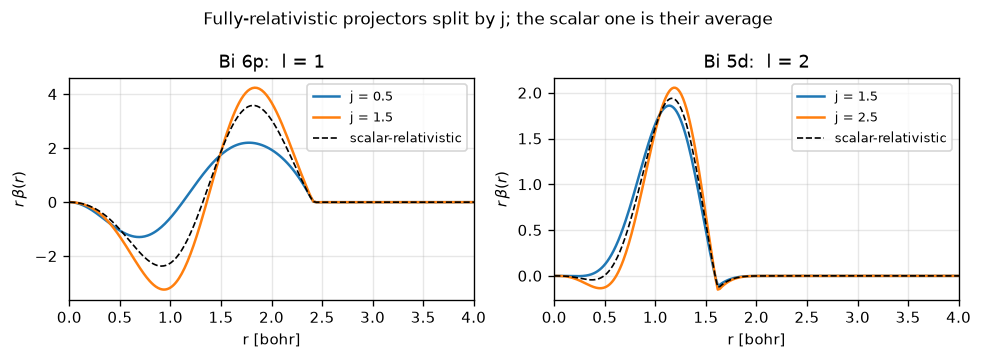

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator
from pypresso.io import read_qe_output
from pypresso.pseudo import read_upf
from pypresso.units import RY_TO_EV

QE = Path("../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite")
PSEUDO, CASES = Path("../tests/data/pseudo"), Path("../tests/data/qe")
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3})


def load(path):
    return Calculator.from_file(path, pseudo_dir=PSEUDO, announce=False,
                                conv_thr=1e-10)


# A fully-relativistic dataset keeps two projectors where a scalar one keeps their average:
# j = l - 1/2 and j = l + 1/2, which is where the coupling physically lives.
relativistic = read_upf(PSEUDO / "Bi.rel-pbe-dn-rrkjus_psl.1.0.0.UPF")
scalar = read_upf(PSEUDO / "Bi.pbe-dn-rrkjus_psl.1.0.0.UPF")
for name, pseudo in (("Bi.rel-pbe-dn-rrkjus", relativistic), ("Bi.pbe-dn-rrkjus", scalar)):
    print("%-22s %2d projectors  has_so=%-5s  (l, j) = %s"
          % (name, pseudo.nbeta, pseudo.has_so,
             [(p.l, p.j) for p in pseudo.projectors]))

fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.0))
for ax, l, label in ((axes[0], 1, "6p"), (axes[1], 2, "5d")):
    seen = set()
    for projector in relativistic.projectors:
        if projector.l != l or projector.j in seen:
            continue
        seen.add(projector.j)
        ax.plot(relativistic.r, projector.beta, label="j = %g" % projector.j)
    beta = next(p for p in scalar.projectors if p.l == l)
    ax.plot(scalar.r, beta.beta, "k--", lw=1.0, label="scalar-relativistic")
    ax.set_xlim(0, 4.0); ax.set_xlabel("r [bohr]")
    ax.set_ylabel(r"$r\,\beta(r)$"); ax.set_title("Bi %s:  l = %d" % (label, l))
    ax.legend(fontsize=8)
fig.suptitle("Fully-relativistic projectors split by j; the scalar one is their average",
             fontsize=10)
fig.tight_layout()

## The limit that has to come out right

A spinor calculation with a *scalar* dataset, where the two components cannot mix, must
reproduce the collinear answer term by term with every eigenvalue simply doubled. This is
silicon, `noncolin = .true.` and nothing else changed.

In [2]:
import tempfile

text = (QE / "pw_scf" / "scf.in").read_text()
marker = text.lower().index("&system") + len("&system")
smeared = (text[:marker]
           + "\n    occupations='smearing', smearing='gaussian', degauss=0.02,\n"
           + text[marker:])
work = Path(tempfile.mkdtemp())
(work / "collinear.in").write_text(smeared)
(work / "noncollinear.in").write_text(
    smeared[:marker] + "\n    noncolin = .true.,\n" + smeared[marker:])

collinear_calc = load(work / "collinear.in")
spinor_calc = load(work / "noncollinear.in")
for label, s in (("collinear   ", collinear_calc.system),
                 ("noncollinear", spinor_calc.system)):
    print("%s:  nspin=%d npol=%d nspin_mag=%d"
          % (label, s.nspin, s.npol, s.nspin_mag))
print("             ^ nspin_mag is one: there is no magnetization to carry")

collinear = collinear_calc.get_scf(max_iterations=80)
spinor = spinor_calc.get_scf(max_iterations=80)
print("\n%14s %18s %18s %12s" % ("term", "collinear", "noncollinear", "difference"))
for term, value in collinear.energy_terms.items():
    print("%14s %18.12f %18.12f %12.1e"
          % (term, value, spinor.energy_terms[term], spinor.energy_terms[term] - value))
print("%14s %18.12f %18.12f %12.1e"
      % ("TOTAL", collinear.total_energy, spinor.total_energy,
         spinor.total_energy - collinear.total_energy))

doubled = np.repeat(collinear.eigenvalues, 2, axis=1)
n = doubled.shape[1]
print("\neigenvalues: %d bands -> %d, max |difference from doubling| = %.2e eV"
      % (collinear.eigenvalues.shape[1], spinor.eigenvalues.shape[1],
         np.abs(spinor.eigenvalues[:, :n] - doubled).max() * RY_TO_EV))

collinear   :  nspin=1 npol=1 nspin_mag=1
noncollinear:  nspin=4 npol=2 nspin_mag=1
             ^ nspin_mag is one: there is no magnetization to carry



          term          collinear       noncollinear   difference
  one-electron     4.833721601574     4.833721601574     -6.2e-15
       hartree     1.084391608208     1.084391608208      2.4e-15
            xc    -4.812850203017    -4.812850203017      0.0e+00
         ewald   -16.899758577223   -16.899758577223      0.0e+00
      smearing    -0.000000000418    -0.000000000418     -1.0e-19
         TOTAL   -15.794495570876   -15.794495570876     -3.6e-15

eigenvalues: 8 bands -> 16, max |difference from doubling| = 5.44e-14 eV


## Platinum, against Quantum ESPRESSO

Three of QE's own benchmarks, on the three kinds of dataset that carry $j$. Note the
k-point weights: they sum to **one**, not two, because a spinor band holds one electron.

In [3]:
rows = []
for name, stem, label in (("spinorbit.in", "pw_spinorbit-spinorbit", "ultrasoft, LDA"),
                          ("spinorbit-pbe.in", "pw_spinorbit-spinorbit-pbe",
                           "ultrasoft, PBE"),
                          ("spinorbit-paw.in", "pw_spinorbit-spinorbit-paw", "PAW, PBE")):
    reference = read_qe_output(CASES / f"reference.out.{stem}")
    result = load(QE / "pw_spinorbit" / name).get_scf(max_iterations=100)
    eigen = np.abs(np.asarray(result.eigenvalues) * RY_TO_EV
                   - np.squeeze(np.asarray(reference.eigenvalues))).max()
    rows.append((label, result, reference, eigen))
    if name == "spinorbit.in":
        pt = result

print("%16s %18s %18s %10s %12s"
      % ("dataset", "pypresso (Ry)", "QE 7.5 (Ry)", "dE", "max de (eV)"))
for label, result, reference, eigen in rows:
    print("%16s %18.9f %18.9f %10.1e %12.1e"
          % (label, result.total_energy, reference.total_energy,
             result.total_energy - reference.total_energy, eigen))

levels = np.asarray(pt.eigenvalues)
print("\nmax Kramers splitting over all k: %.1e eV"
      % (np.abs(levels[:, 0::2] - levels[:, 1::2]).max() * RY_TO_EV))
print("(inversion and time reversal both hold, so every level is doubly degenerate)")

         dataset      pypresso (Ry)        QE 7.5 (Ry)         dE  max de (eV)
  ultrasoft, LDA      -69.491529507      -69.491529520    1.3e-08      3.6e-04
  ultrasoft, PBE      -90.199533906      -90.199533910    3.8e-09      2.4e-04
        PAW, PBE     -753.342691622     -753.342691630    8.4e-09      1.0e-04

max Kramers splitting over all k: 1.1e-13 eV
(inversion and time reversal both hold, so every level is doubly degenerate)


## Forces and the stress of a spinor

A spinor ground state has a force and a stress like any other, obtained by differentiating
the total energy at frozen wavefunctions. The figure is that force against a central
difference of the *converged* energy along a bond of doubled fcc platinum: two independent
routes to the same derivative, neither of them involving Quantum ESPRESSO.

   u      F (autodiff)     -dE/du        difference
 0.04      +0.046206      +0.046195      1.1e-05
 0.08      +0.040065      +0.040081      1.5e-05
 0.12      +0.033999      +0.034043      4.4e-05


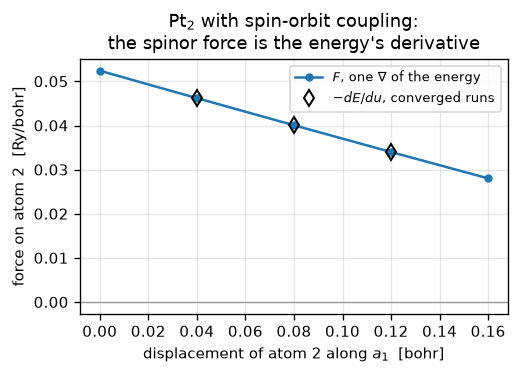

In [4]:
platinum = Calculator.from_file(CASES / "pt2-soc-force.in", pseudo_dir=PSEUDO,
                                announce=False, conv_thr=1e-10)
p0 = np.asarray(platinum.system.structure.positions)

shifts = np.array([0.0, 0.04, 0.08, 0.12, 0.16])
energies, forces = [], []
for u in shifts:
    moved = p0.copy()
    moved[1, 0] += u
    here = platinum.with_positions(moved)
    energies.append(here.get_scf().total_energy)
    forces.append(float(np.asarray(here.get_forces().forces)[1, 0]))
energies, forces = np.array(energies), np.array(forces)

# -dE/du by a central difference of the converged energies, at the interior points.
fd = -(energies[2:] - energies[:-2]) / (shifts[2:] - shifts[:-2])
print("   u      F (autodiff)     -dE/du        difference")
for u, f, d in zip(shifts[1:-1], forces[1:-1], fd):
    print("%5.2f    %+11.6f    %+11.6f    %9.1e" % (u, f, d, abs(f - d)))

fig, ax = plt.subplots(figsize=(4.4, 3.2))
ax.plot(shifts, forces, "-o", ms=4, label=r"$F$, one $\nabla$ of the energy")
ax.plot(shifts[1:-1], fd, "kd", ms=7, mfc="none", mew=1.2,
        label=r"$-dE/du$, converged runs")
ax.axhline(0.0, lw=0.8, color="0.6")
ax.set_xlabel("displacement of atom 2 along $a_1$  [bohr]")
ax.set_ylabel("force on atom 2  [Ry/bohr]")
ax.set_title("Pt$_2$ with spin-orbit coupling:\nthe spinor force is the energy's derivative")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

The two agree to about $10^{-5}$ Ry/bohr, which is the central difference's own floor at
this step. Against `pw.x`, which computes both quantities for a spinor run, the force
agrees to **8.9e-7 Ry/bohr** on a four-atom noncollinear hydrogen chain, **7.5e-6** on
this ultrasoft platinum and **7.3e-7** on its PAW twin, with the stress on those three
plus the three benchmarks above to **1.2e-6 Ry/bohr³ or better**.

Relaxation follows from the force: BFGS puts this displaced platinum back in **8 ionic
steps**, to a maximum force of 8.96e-5 Ry/bohr and the two atoms 0.499945 of a cell apart,
against the half that symmetry requires. It is the *separation* that is meaningful, since
subtracting the mean force leaves a rigid translation of the whole crystal free.

Refused for a spinor run: phonons and everything else that needs a linear response solve,
the elastic constants, electrostriction, and the force on an atom of a spin spiral, whose
two spinor components live on different plane-wave spheres.

## Bismuthene: a gap made entirely of spin-orbit coupling

Two bismuth atoms in a honeycomb layer. Without the coupling the bands cross near K in a
Dirac point; with it they do not, and what opens is a gap of about half an electronvolt.
The result is a quantum spin Hall insulator, whose invariant notebook 10 computes: the gap
is not a band-structure detail but the thing that makes the material topological, and it
exists only because bismuth is heavy.

Run at the test size (20 Ry, 6x6x1). The converged pair (35 Ry, 12x12x1) is committed
beside it with its own QE reference and takes about forty minutes at a peak of 9.4 GB;
the small pair is what the regression tests check.

In [5]:
SIZE = "-small"
CORNERS = {"Gamma": 0, "M": 4, "K": 7, "Gamma'": 12}

results, bands = {}, {}
for tag in ("nosoc", "soc"):
    calc = load(CASES / f"bismuthene-{tag}{SIZE}.in")
    system = calc.system
    results[tag] = calc.get_scf(max_iterations=100)
    # Only the k-path comes from the bands input; the density is already here,
    # and so is the Fermi level the plot puts at zero.
    path_system = load(CASES / f"bismuthene-{tag}{SIZE}-bands.in").system
    bands[tag] = calc.get_bands(kpoints=path_system.kpoints, nbnd=path_system.nbnd)
    reference = read_qe_output(CASES / f"reference.out.bismuthene-{tag}{SIZE}")
    nelec = sum(calc.pseudos[t].z_valence for t in system.structure.types)
    occupied = int(round(nelec / (1 if system.nspin == 4 else 2)))
    levels = bands[tag].eigenvalues_ev
    direct = levels[:, occupied] - levels[:, occupied - 1]
    print("%6s: nspin=%d npol=%d, E = %.9f Ry (QE %.1e), smallest direct gap %.4f eV"
          % (tag, system.nspin, system.npol, results[tag].total_energy,
             results[tag].total_energy - reference.total_energy, direct.min()))

 nosoc: nspin=1 npol=1, E = -296.198423399 Ry (QE -3.4e-05), smallest direct gap 0.1361 eV


   soc: nspin=4 npol=2, E = -295.610317533 Ry (QE -3.5e-05), smallest direct gap 0.6295 eV


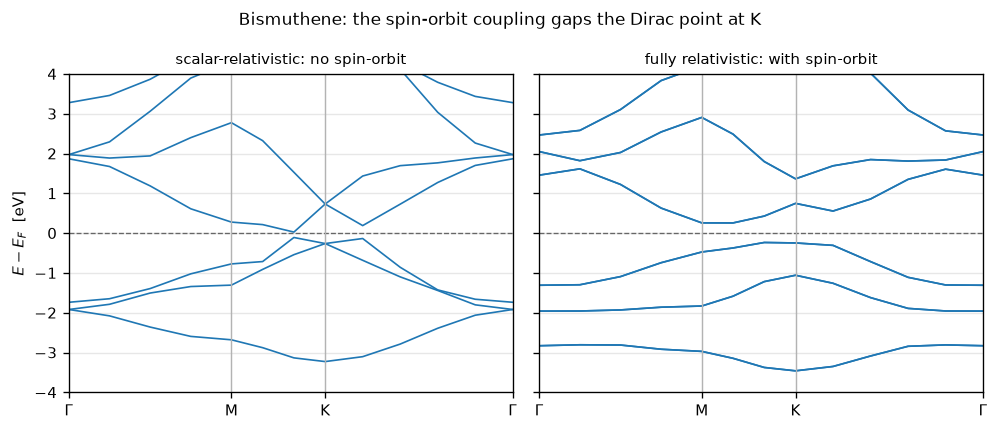

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.6), sharey=True)
for ax, tag, title in ((axes[0], "nosoc", "scalar-relativistic: no spin-orbit"),
                       (axes[1], "soc", "fully relativistic: with spin-orbit")):
    x = bands[tag].path_length
    ax.plot(x, bands[tag].eigenvalues_ev - results[tag].fermi_energy * RY_TO_EV,
            color="#1f77b4", lw=1.0)
    ax.axhline(0.0, color="0.4", lw=0.8, ls="--")
    corners = list(CORNERS.values())
    for c in corners[1:-1]:
        ax.axvline(x[c], color="0.7", lw=0.8)
    ax.set_xticks([x[c] for c in corners])
    ax.set_xticklabels([r"$\Gamma$", "M", "K", r"$\Gamma$"])
    ax.set_xlim(x[0], x[-1]); ax.set_ylim(-4.0, 4.0); ax.set_title(title, fontsize=9)
axes[0].set_ylabel(r"$E - E_F$  [eV]")
fig.suptitle("Bismuthene: the spin-orbit coupling gaps the Dirac point at K", fontsize=10)
fig.tight_layout()

---
The tests behind this notebook: `tests/regression/test_spinorbit.py`,
`tests/unit/test_spinorbit_coefficients.py`.